<a href="https://colab.research.google.com/github/AHamamd150/KEK_Lectures/blob/main/notebooks/Lecture3_CNN_GalaxyZoo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Galaxy Morphology Classification with a CNN


**Goal:** Train a CNN to classify galaxy images into 10 morphological types  
**Dataset:** Galaxy10 DECals — 17,736 galaxy images, resized to 64×64 pixels, 3 colour bands (g, r, z)  

> **Note on memory:** The native Galaxy10 DECals images are 256×256 pixels. Loading them all
> as float32 requires ~14 GB — exceeding Colab free tier RAM and crashing the session.
> This notebook loads images one at a time from the HDF5 file, resizes to 64×64, and
> normalises on the fly, keeping peak memory under 1 GB.

---
| Label | Galaxy Type |
|-------|-------------|
| 0 | Disturbed Galaxies |
| 1 | Merging Galaxies |
| 2 | Round Smooth Galaxies |
| 3 | In-between Round Smooth Galaxies |
| 4 | Cigar Shaped Smooth Galaxies |
| 5 | Barred Spiral Galaxies |
| 6 | Unbarred Tight Spiral Galaxies |
| 7 | Unbarred Loose Spiral Galaxies |
| 8 | Edge-on Galaxies without Bulge |
| 9 | Edge-on Galaxies with Bulge |

---

## Step 0 — Install Dependencies

`astroNN` is used to trigger the one-time download of the Galaxy10 HDF5 file (~1 GB).  
After that we read directly from the file using `h5py` to avoid memory issues.  
Run this cell only once per Colab session.

In [ ]:
!pip install astroNN tensorflow scikit-learn matplotlib h5py Pillow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 36.1 MB/s eta 0:00:00


## Step 1 — Import Libraries

In [ ]:
import os
import numpy as np                                       # Array and numerical operations
import matplotlib.pyplot as plt                          # Plotting and visualization
import h5py                                              # Read HDF5 files directly (memory-efficient)
from PIL import Image as PILImage                        # Resize individual images on the fly

from astroNN.datasets.galaxy10 import Galaxy10Class      # Dict: {0: 'Disturbed', 1: 'Merging', ...}

from sklearn.model_selection import train_test_split     # Splits data into train/test sets

import tensorflow as tf                                  # Deep learning framework
from tensorflow.keras import layers, models              # Building blocks for the CNN

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


## Step 2 — Download and Load the Dataset (Memory-Safe)

### Why not just call `load_galaxy10()`?

| Approach | Peak RAM | Result on Colab free tier |
|----------|----------|---------------------------|
| `load_galaxy10()` then `.astype('float32')` | ~28 GB | Session crash |
| Load via h5py, resize + normalise per image | ~0.9 GB | Works fine |

The native images are **256×256** pixels. Converting all 17,736 of them to float32
requires 13.9 GB, and `.astype()` briefly holds **two copies** in RAM (28 GB peak).

**Fix:** Open the HDF5 file directly with `h5py`, read **one image at a time**,
resize to **64×64** pixels, and normalise immediately. The final array is only 0.87 GB.
There is no loss in classification quality — 64×64 retains all morphological features
needed by the CNN.

In [ ]:
import os, h5py, cv2, numpy as np
from concurrent.futures import ThreadPoolExecutor

H5_PATH    = os.path.expanduser('~/.astroNN/datasets/Galaxy10_DECals.h5')
TARGET_SIZE = (64, 64)   # (W, H) for cv2
BATCH_SIZE  = 512        # tune to your RAM; larger = fewer HDF5 round-trips
N_WORKERS   = os.cpu_count()  # one thread per logical core

# ── download if needed ────────────────────────────────────────────────────────
if not os.path.exists(H5_PATH):
    print('Downloading Galaxy10 DECals (~1 GB) …')
    from astroNN.datasets import load_galaxy10
    load_galaxy10()
    import gc; gc.collect()
    print('Download complete.')
else:
    print('HDF5 file already present:', H5_PATH)

print(f'\nLoading and resizing to {TARGET_SIZE[0]}×{TARGET_SIZE[1]} …')

def resize_batch(batch_uint8):
    """Resize a (B, 256, 256, 3) uint8 array → (B, 64, 64, 3) float32."""
    B = batch_uint8.shape[0]
    out = np.empty((B, TARGET_SIZE[1], TARGET_SIZE[0], 3), dtype='float32')
    for j in range(B):
        out[j] = cv2.resize(batch_uint8[j], TARGET_SIZE,
                            interpolation=cv2.INTER_LINEAR)
    out /= 255.0
    return out

with h5py.File(H5_PATH, 'r') as f:
    raw_images = f['images']               # (17736, 256, 256, 3) uint8, lazy
    labels     = f['ans'][:]               # load all labels at once (tiny)
    n          = raw_images.shape[0]

    images = np.empty((n, TARGET_SIZE[1], TARGET_SIZE[0], 3), dtype='float32')

    # Slice indices for each batch
    slices = [(i, min(i + BATCH_SIZE, n)) for i in range(0, n, BATCH_SIZE)]

    def process_slice(args):
        start, end = args
        batch = raw_images[start:end]      # one efficient HDF5 read per batch
        images[start:end] = resize_batch(batch)
        print(f'  {end}/{n} processed …')

    with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
        list(pool.map(process_slice, slices))  # list() forces completion

print('\nDone.')
print('images shape :', images.shape)
print('labels shape :', labels.shape)
print('Pixel range  : [{:.1f}, {:.1f}]'.format(images.min(), images.max()))
print('RAM used     : ~{:.2f} GB'.format(images.nbytes / 1e9))

HDF5 file already present: /root/.astroNN/datasets/Galaxy10_DECals.h5

Loading and resizing to 64×64 …
  512/17736 processed …
  1024/17736 processed …
  1536/17736 processed …
  2048/17736 processed …
  2560/17736 processed …
  3072/17736 processed …
  3584/17736 processed …
  4096/17736 processed …
  4608/17736 processed …
  5120/17736 processed …
  5632/17736 processed …
  6144/17736 processed …
  6656/17736 processed …
  7168/17736 processed …
  7680/17736 processed …
  8192/17736 processed …
  8704/17736 processed …
  9216/17736 processed …
  9728/17736 processed …
  10240/17736 processed …
  10752/17736 processed …
  11264/17736 processed …
  11776/17736 processed …
  12288/17736 processed …
  12800/17736 processed …
  13312/17736 processed …
  13824/17736 processed …
  14336/17736 processed …
  14848/17736 processed …
  15360/17736 processed …
  15872/17736 processed …
  16384/17736 processed …
  16896/17736 processed …
  17408/17736 processed …
  17736/17736 processed …

Done.


## Step 3 — Visualize Sample Images

Always look at your data before training.  
This is the equivalent of checking your detector plots before a physics analysis.

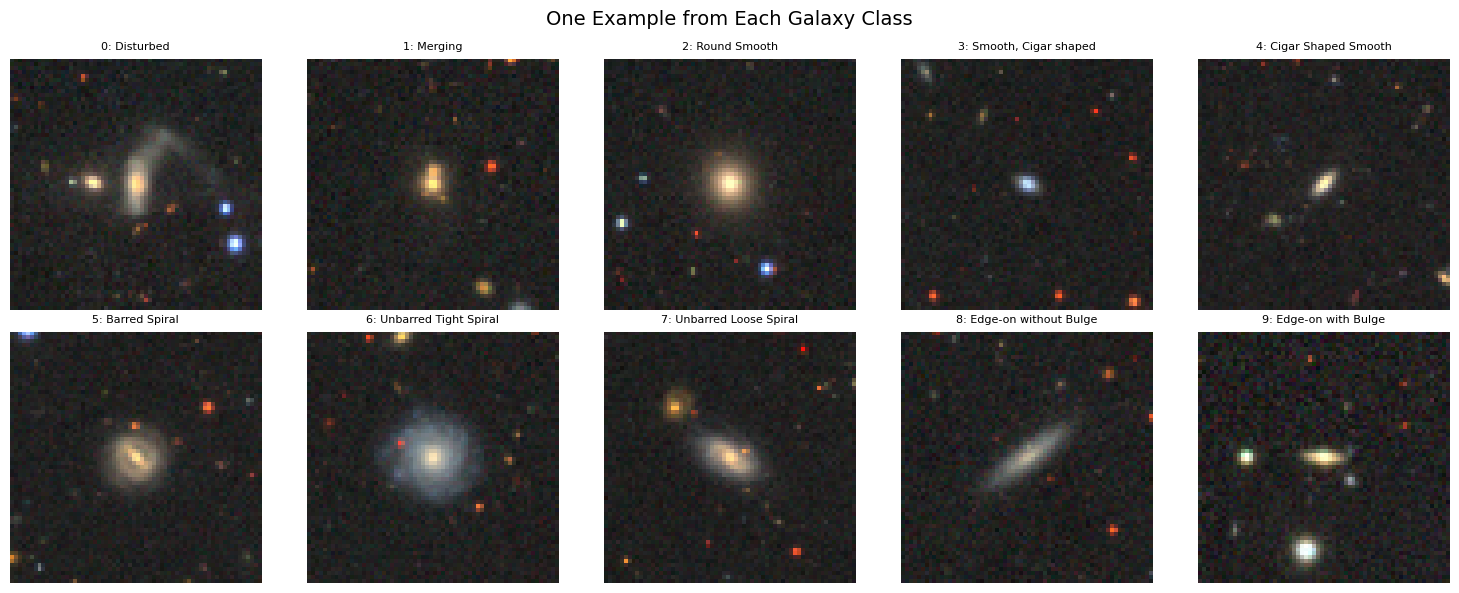

In [ ]:
# Galaxy10Class is a dict: {0: 'Disturbed', 1: 'Merging', ...}
class_names = Galaxy10Class

# Plot one example image from each of the 10 galaxy classes
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('One Example from Each Galaxy Class', fontsize=14)

for class_id in range(10):
    idx = np.where(labels == class_id)[0][0]      # First image index for this class
    ax  = axes[class_id // 5][class_id % 5]       # Place in 2x5 grid
    ax.imshow(images[idx])                         # images are already in [0,1] float
    ax.set_title(f'{class_id}: {class_names[class_id]}', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Step 4 — Train / Test Split

Normalisation (dividing by 255) was already done during loading in Step 2.  
The only remaining preprocessing step is splitting into training and test sets.

- **80%** of images go to training
- **20%** are held out completely for final evaluation
- `random_state=42` guarantees the same split every run

In [ ]:
# Note: normalisation was already applied during loading (divided by 255.0 on the fly)
# We only need the train/test split here
X_train, X_test, y_train, y_test = train_test_split(
    images, labels,
    test_size=0.2,
    random_state=42
)

print('Training samples  :', X_train.shape[0])   # ~14188
print('Test samples      :', X_test.shape[0])     # ~3548
print('Image shape       :', X_train.shape[1:])   # (64, 64, 3)

Training samples  : 14188
Test samples      : 3548
Image shape       : (64, 64, 3)


## Step 5 — Build the CNN Architecture

A simple 3-block CNN. Each block follows the same pattern:  
`Conv2D -> ReLU activation -> MaxPooling`

```
Input Image (64x64x3)
       |
  [Conv Block 1]  ->  32 filters, learns low-level features (edges, colour gradients)
       |
  [Conv Block 2]  ->  64 filters, learns mid-level features (bars, disks, arm segments)
       |
  [Conv Block 3]  ->  128 filters, learns high-level shapes (spiral vs elliptical)
       |
    Flatten        ->  converts 2D feature maps into a 1D vector
       |
  Dense (256)      ->  combines all learned features
       |
  Dense (10)       ->  probability for each of the 10 classes
```

**HEP analogy:** Conv layers are a hierarchy of pattern matchers:  
pixels -> edges (tracker hits) -> local structures (track segments) -> global topology (jet shape).

In [ ]:
model = models.Sequential([

    # INPUT: shape is now (64, 64, 3) after resizing in Step 2
    layers.Input(shape=(64, 64, 3)),

    # CONV BLOCK 1
    # 32 filters of size 3x3: each filter slides over the image and detects a local pattern
    # 'relu' sets negative values to zero, introducing non-linearity
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    # MaxPooling halves spatial dimensions by keeping the max value in each 2x2 window
    # Makes the network robust to small shifts in galaxy position (translation invariance)
    layers.MaxPooling2D(pool_size=(2, 2)),

    # CONV BLOCK 2
    # 64 filters: more filters = more diverse patterns detectable at this level
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # CONV BLOCK 3
    # 128 filters: at this depth, filters respond to high-level structures
    # (full spiral arms, galactic bulges, edge-on disks)
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # FLATTEN: unroll the 3D feature maps into a single 1D vector
    # This vector is the CNN's learned descriptor of the galaxy
    layers.Flatten(),

    # DENSE CLASSIFIER: combines all learned features
    layers.Dense(256, activation='relu'),

    # Dropout: randomly disables 40% of neurons during training to prevent overfitting
    # Forces the network not to rely on any single feature too heavily
    layers.Dropout(0.4),

    # OUTPUT: 10 neurons, one per galaxy class
    # 'softmax' converts raw scores into probabilities that sum to 1.0
    layers.Dense(10, activation='softmax')
])

# Print a summary: layer names, output shapes, and number of trainable parameters
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,275,722 (4.87 MB)

 Trainable params: 1,275,722 (4.87 MB)

 Non-trainable params: 0 (0.00 B)

## Step 6 — Compile the Model

| Setting | Choice | Why |
|---------|--------|-----|
| **Optimizer** | Adam | Adaptive learning rate, works well out of the box |
| **Loss** | Sparse categorical cross-entropy | Standard loss for multi-class integer labels |
| **Metric** | Accuracy | Fraction of galaxies correctly classified |

**HEP analogy:** The loss function is like a negative log-likelihood.  
Minimizing it pushes predicted class probabilities toward the true labels.

In [ ]:
model.compile(
    optimizer='adam',                           # Adam: gradient descent with adaptive learning rates
    loss='sparse_categorical_crossentropy',     # Loss for integer class labels (not one-hot encoded)
    metrics=['accuracy']                        # Track classification accuracy during training
)

## Step 7 — Train the Model

- **Epoch:** One full pass through all training images. We do 15 passes.
- **Batch size:** The network sees 64 images at a time before updating its weights.
- **Validation split:** 10% of training data is held out each epoch to monitor overfitting.

*Expect ~70-80% validation accuracy after 15 epochs.*  
*On Colab CPU: ~3-5 min. On Colab GPU (Runtime -> Change runtime type -> T4 GPU): ~30 sec.*

In [ ]:
history = model.fit(
    X_train, y_train,       # Training images and their true labels
    epochs=15,              # Number of full passes through the training data
    batch_size=64,          # Process 64 images at a time before each weight update
    validation_split=0.1,   # Hold out 10% of training data to monitor overfitting
    verbose=1               # Print loss and accuracy after each epoch
)
# 'history' stores loss and accuracy at every epoch — we plot this next

Epoch 1/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.2996 - loss: 1.8766 - val_accuracy: 0.4489 - val_loss: 1.5072
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4746 - loss: 1.4319 - val_accuracy: 0.5264 - val_loss: 1.3003
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5466 - loss: 1.2652 - val_accuracy: 0.5849 - val_loss: 1.1770
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6019 - loss: 1.1321 - val_accuracy: 0.6251 - val_loss: 1.0922
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6366 - loss: 1.0255 - val_accuracy: 0.6328 - val_loss: 1.0742
Epoch 6/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6723 - loss: 0.9362 - val_accuracy: 0.6674 - val_loss: 0.9612
Epoch 7/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6876 - loss: 0.8728 - val_accuracy: 0.6568 - val_loss: 0.9844
Epoch 8/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7225 - loss: 0.7920 - val_acc

## Step 8 — Plot Training History

Equivalent to watching your fit converge in MINUIT.

- **Training loss going down** = the network is learning
- **Validation loss diverging upward** = overfitting (memorising training data)
- **Both curves tracking closely** = good generalisation

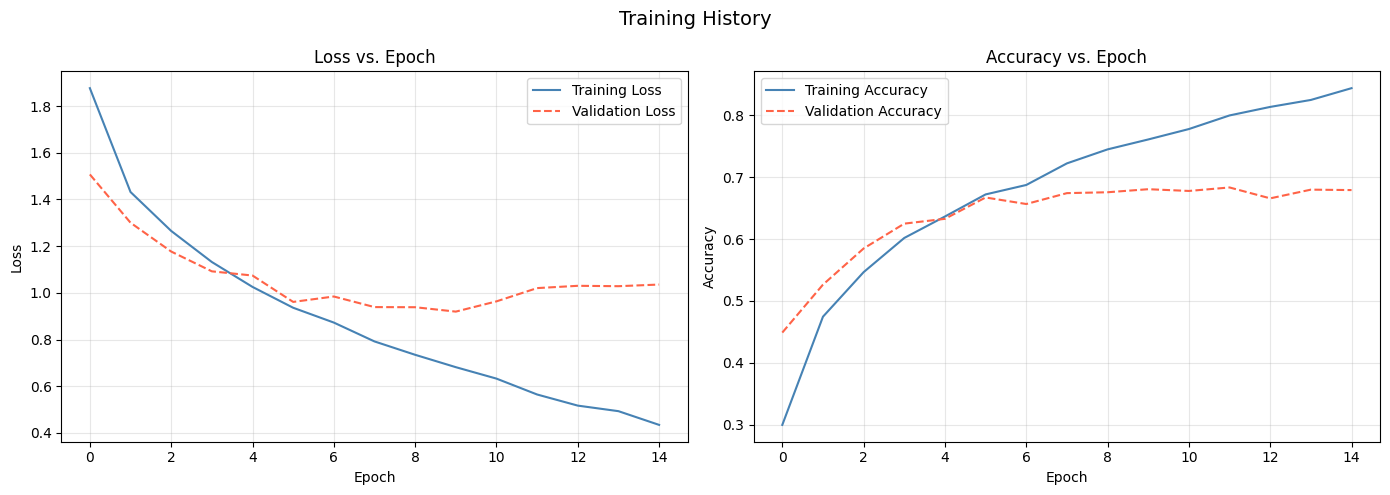

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Loss curves
ax1.plot(history.history['loss'],     label='Training Loss',   color='steelblue')
ax1.plot(history.history['val_loss'], label='Validation Loss', color='tomato', linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss vs. Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right plot: Accuracy curves
ax2.plot(history.history['accuracy'],     label='Training Accuracy',   color='steelblue')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='tomato', linestyle='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy vs. Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=14)
plt.tight_layout()
plt.show()

## Step 9 — Evaluate on the Test Set

The test set was completely untouched during training.  
This gives an honest estimate of performance on new, unseen galaxies.

In [ ]:
# Evaluate the trained model on the held-out test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_accuracy*100:.1f}%')   # Expect ~70-80%

Test Loss     : 1.0517
Test Accuracy : 70.3%


## Step 10 — Confusion Matrix

Shows which classes the network confuses with each other.  
More informative than a single accuracy number.

**HEP analogy:** This is your signal/background efficiency matrix.  
Diagonal = correctly classified. Off-diagonal = misclassified.

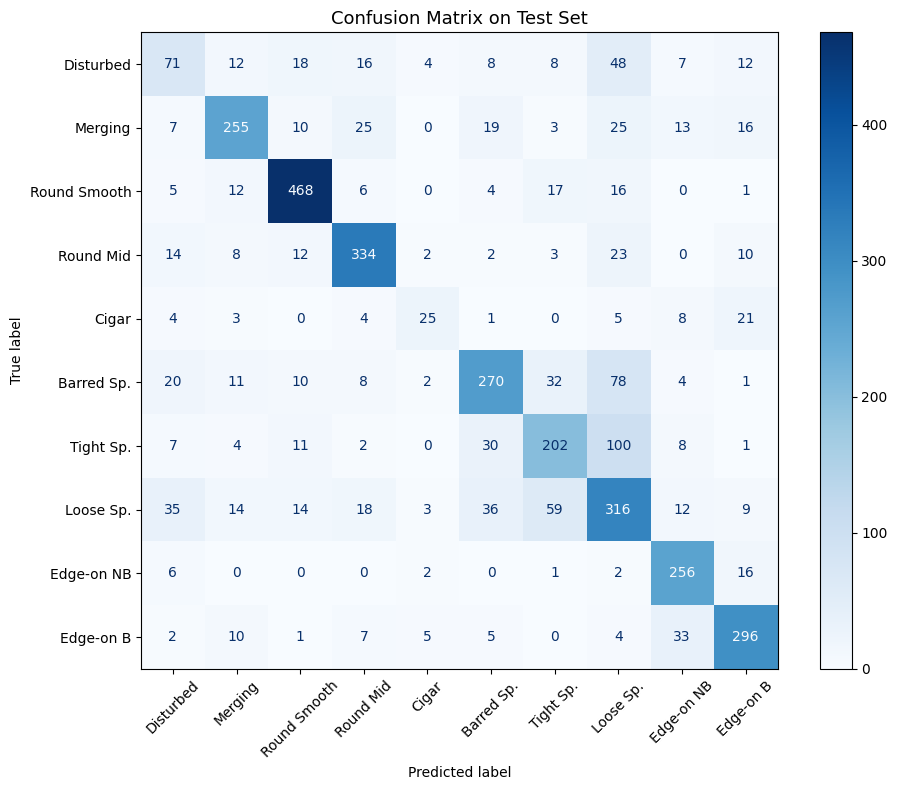

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# model.predict() returns softmax probabilities; argmax picks the highest-probability class
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

# Build confusion matrix: rows = true class, columns = predicted class
cm = confusion_matrix(y_test, y_pred)

short_labels = [
    'Disturbed', 'Merging', 'Round Smooth', 'Round Mid',
    'Cigar', 'Barred Sp.', 'Tight Sp.', 'Loose Sp.',
    'Edge-on NB', 'Edge-on B'
]

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=short_labels)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title('Confusion Matrix on Test Set', fontsize=13)
plt.tight_layout()
plt.show()

# Discussion: which classes are most confused, and does that make physical sense?

## Step 11 — Visualize Predictions on Individual Galaxies

Look at 10 random test galaxies and see what the network predicted.  
**Green title** = correct prediction. **Red title** = wrong prediction.

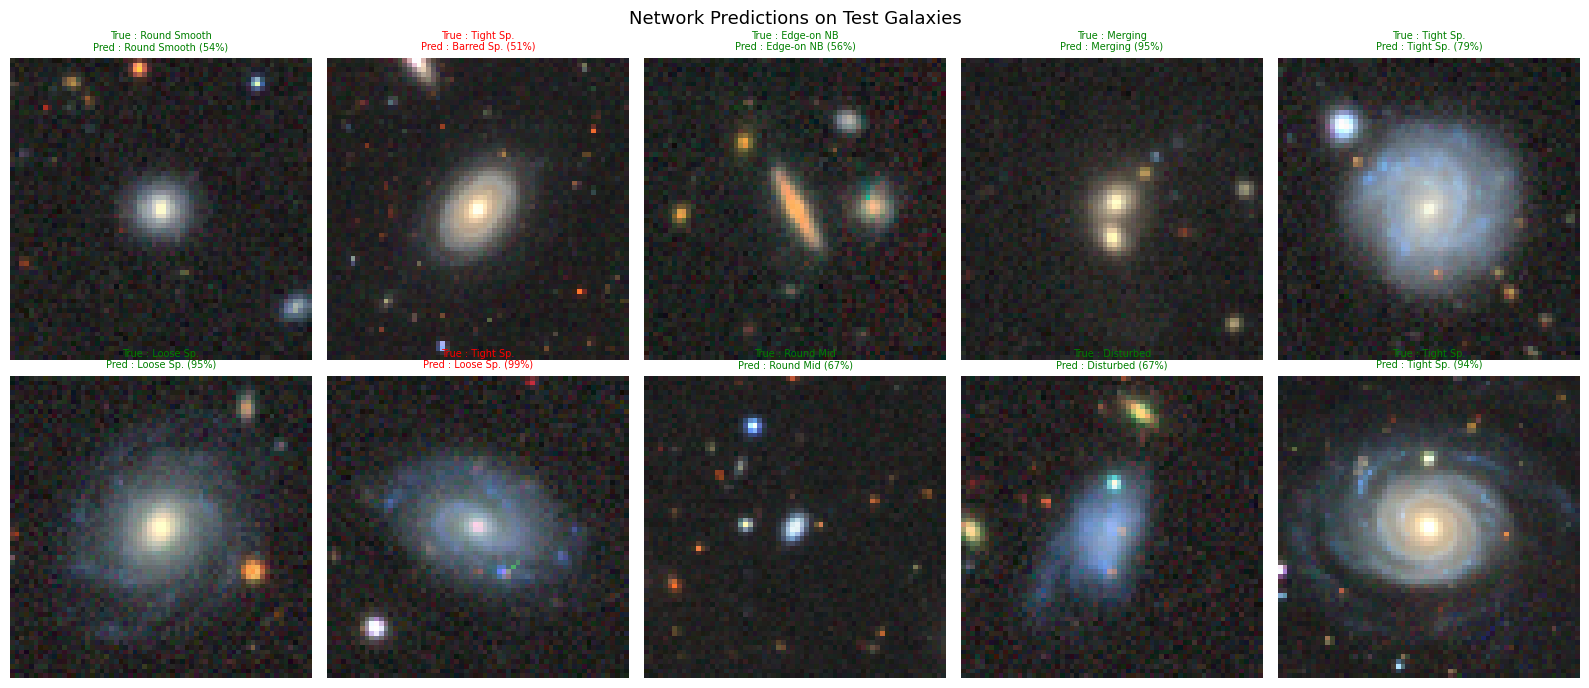

In [ ]:
# Get predicted probabilities for all test images
y_proba = model.predict(X_test, verbose=0)   # Shape: (n_test, 10)

# Pick 10 random test images to inspect
rng = np.random.default_rng(seed=0)
sample_idx = rng.choice(len(X_test), size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Network Predictions on Test Galaxies', fontsize=13)

for i, idx in enumerate(sample_idx):
    ax = axes[i // 5][i % 5]
    ax.imshow(X_test[idx])

    true_class = y_test[idx]
    pred_class = np.argmax(y_proba[idx])          # Class with highest predicted probability
    confidence = y_proba[idx][pred_class] * 100   # Confidence in percent

    color = 'green' if pred_class == true_class else 'red'
    ax.set_title(
        f'True : {short_labels[true_class]}\nPred : {short_labels[pred_class]} ({confidence:.0f}%)',
        fontsize=7, color=color
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

## Step 12 — (Bonus) Visualize What the First Conv Layer Learned

Directly inspect the 32 learned filters of the first convolutional layer.  
Each filter is a 3x3 patch of weights the network discovered from the data.

**Key insight:** Nobody told the network what to look for.  
It discovered these feature detectors by itself from galaxy images and their labels.

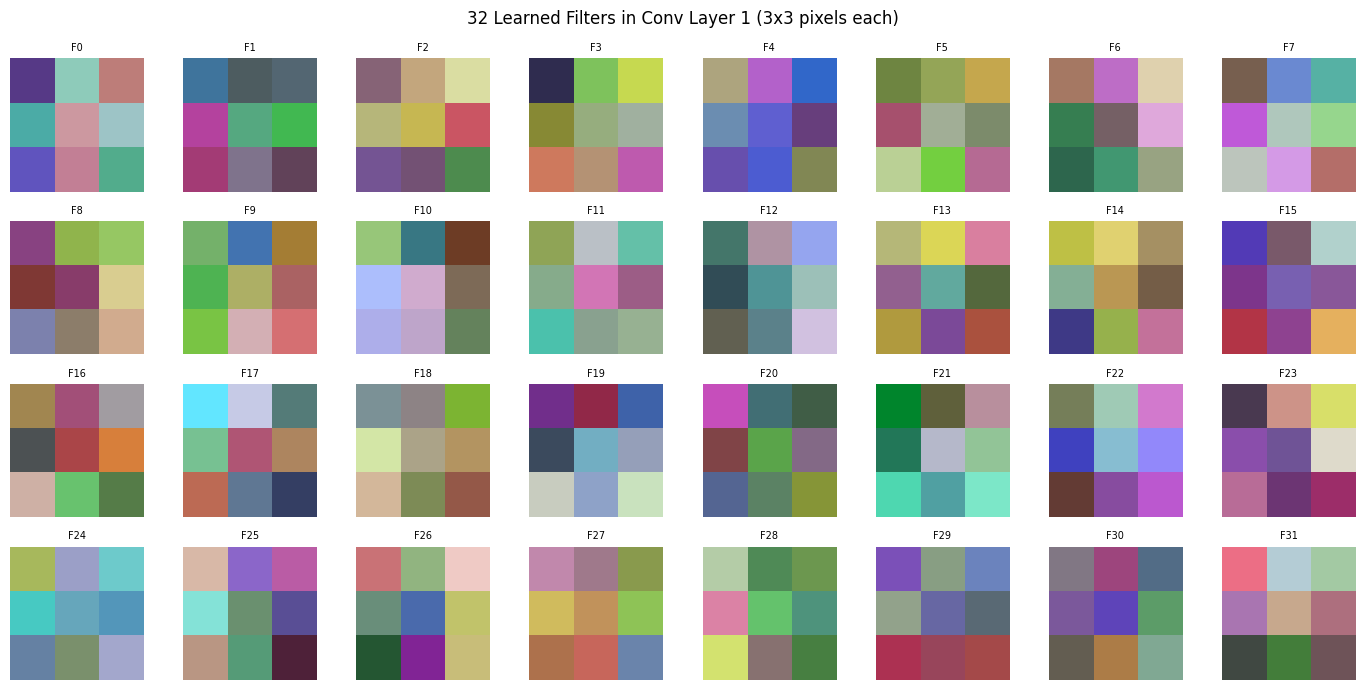

In [ ]:
# Extract weights from the first Conv2D layer
# Shape: (3, 3, 3, 32) = (filter_height, filter_width, input_channels, num_filters)
filters, biases = model.layers[0].get_weights()

# Normalize filter weights to [0, 1] for display
f_min, f_max = filters.min(), filters.max()
filters_norm = (filters - f_min) / (f_max - f_min)

# Plot all 32 learned filters in a 4x8 grid
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
fig.suptitle('32 Learned Filters in Conv Layer 1 (3x3 pixels each)', fontsize=12)

for i in range(32):
    ax = axes[i // 8][i % 8]
    ax.imshow(filters_norm[:, :, :, i])   # The i-th filter as an RGB patch
    ax.set_title(f'F{i}', fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Some filters detect horizontal edges, some colour gradients, some diagonals.
# The network invented these feature detectors itself — no physicist designed them.

---
## Summary

| Step | What We Did | Notes |
|------|-------------|-------|
| Load data | h5py + per-image resize to 64x64 | Avoids Colab RAM crash |
| Preprocess | Normalize on the fly + train/test split | No separate normalization step needed |
| Build CNN | 3 conv blocks + dense head | Input shape (64, 64, 3) |
| Train | `model.fit(...)` 15 epochs | ~30s on GPU, ~5min on CPU |
| Evaluate | Confusion matrix + visual predictions | ~70-80% test accuracy |

### What next?

Use the latent space analysis to get more insight for unsupervised learning analysis.

### References
- Leung & Bovy (2019), MNRAS 483, 3255 — astroNN paper [arXiv:1808.04428](https://arxiv.org/abs/1808.04428)
- Walmsley et al. (2021) — Galaxy Zoo DECaLS campaign
- Dey et al. (2019) — DESI Legacy Imaging Surveys
- Lintott et al. (2008, 2011) — Galaxy Zoo labels